# Library

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

import torch
from torchinfo import summary
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
import random 
import numpy as np
import pandas as pd
from torchinfo import summary
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.utils.data import DataLoader, Dataset
import wandb
from dotenv import load_dotenv
from torchvision.datasets import DatasetFolder
from PIL import Image
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from torch.utils.data import random_split, Subset
import gc
from datetime import datetime
from pytorch_lightning.loggers import WandbLogger
from dino_finetune import DINOV2EncoderLoRA

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from simdinov2.models.return_models import get_dino_finetuned_downloaded

/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/swiglu_ffn.py:43: UserWarning: Using xFormers (SwiGLU)
  warnings.warn("Using xFormers (SwiGLU)")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/attention.py:27: UserWarning: Using xFormers (Attention)
  warnings.warn("Using xFormers (Attention)")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/attention.py:38: UserWarning: Using SDPA Attention
  warnings.warn("Using SDPA Attention")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


# Loading Data

In [2]:
saved_dir = "04-4-2025/npz"

In [3]:
# df_train = pd.read_csv(f"{saved_dir}/train3class.csv") 
# Load train and validation datasets

train = np.load(f"{saved_dir}/train_data.npz")
valid = np.load(f"{saved_dir}/val_data.npz")
test  = np.load(f"{saved_dir}/test_data.npz")

In [4]:

x_train = train['x_train']
y_train_keys = train['y_train']

x_valid = valid['x_val'] 
y_valid_keys = valid['y_val']

x_test = test['x_test']
y_test_keys = test['y_test']

In [5]:
np.unique(y_train_keys)

array(['PB1 Basmati', 'Pusa', 'Pusa 1121 Basmati', 'Pusa 1401 Basmati',
       'Pusa 1509 Basmati', 'Pusa 1718 Basmati', 'Sharbati Rice',
       'Sugandha Basmati', 'TAJ'], dtype='<U17')

In [6]:
Counter(y_train_keys)

Counter({np.str_('Pusa 1509 Basmati'): 45134,
         np.str_('Pusa 1121 Basmati'): 44837,
         np.str_('Sharbati Rice'): 7664,
         np.str_('Pusa 1401 Basmati'): 6823,
         np.str_('Pusa'): 6820,
         np.str_('PB1 Basmati'): 6803,
         np.str_('Pusa 1718 Basmati'): 6588,
         np.str_('TAJ'): 6580,
         np.str_('Sugandha Basmati'): 6524})

In [7]:
#Transform y values from keys to Breed
def transform_breed(breed):
    return "Other" if breed not in ["Pusa 1509 Basmati", "Pusa 1121 Basmati"] else breed
y_train = np.array([transform_breed(key) for key in y_train_keys])
y_valid = np.array([transform_breed(key) for key in y_valid_keys])
y_test = np.array([transform_breed(key) for key in y_test_keys ])

In [8]:
Counter(y_train), Counter(y_valid), Counter(y_test)

(Counter({np.str_('Other'): 47802,
          np.str_('Pusa 1509 Basmati'): 45134,
          np.str_('Pusa 1121 Basmati'): 44837}),
 Counter({np.str_('Pusa 1121 Basmati'): 5634,
          np.str_('Pusa 1509 Basmati'): 5578,
          np.str_('Other'): 3821}),
 Counter({np.str_('Other'): 8360,
          np.str_('Pusa 1121 Basmati'): 5967,
          np.str_('Pusa 1509 Basmati'): 5779}))

In [9]:
# Encode labels using Keras utilities
unique_classes = np.unique(y_train) # extract distinct classes
class_indices = {label: index for index, label in enumerate(unique_classes)} # class with index
y_train_encoded = np.array([class_indices[label] for label in y_train]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_valid_encoded = np.array([class_indices[label] for label in y_valid]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_test_encoded = np.array([class_indices[label] for label in y_test]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]

# Calculate class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = {index: weight for index, weight in enumerate(class_weights)}


In [10]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1509 Basmati'): 2}

In [11]:
intensity_ranges = {
        "brightness": np.linspace(0.9, 1.1, 5),  # Range should be >0
        "contrast": np.linspace(0.9, 1.1, 5),
        "saturation": np.linspace(0.9, 1.1, 5),  # Ensure positive values
        "hue": np.linspace(-0.05, 0.05, 5)  # Hue range should be (-0.5, 0.5)
        }

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image
    # transforms.RandomApply(
    # [transforms.ColorJitter(brightness=(intensity_ranges["brightness"].min(), intensity_ranges["brightness"].max()),
    #                         contrast=(intensity_ranges["contrast"].min(), intensity_ranges["contrast"].max()),
    #                         saturation=(intensity_ranges["saturation"].min(), intensity_ranges["saturation"].max()),
    #                         hue=(intensity_ranges["hue"].min(), intensity_ranges["hue"].max()))],
    #                         p=0.8,),
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize image
])

In [12]:
model_path = "MPIND1/eval/training_18999/teacher_checkpoint.pth" # full training
transformer = get_dino_finetuned_downloaded(model_path=model_path, modelname="dinov2_vitb14_reg")

Using cache found in /home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/easyrice/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [13]:
summary(transformer, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DinoVisionTransformer                    [1, 768]                  201,984
├─PatchEmbed: 1-1                        [1, 256, 768]             --
│    └─Conv2d: 2-1                       [1, 768, 16, 16]          452,352
│    └─Identity: 2-2                     [1, 256, 768]             --
├─ModuleList: 1-2                        --                        --
│    └─NestedTensorBlock: 2-3            [1, 261, 768]             --
│    │    └─LayerNorm: 3-1               [1, 261, 768]             1,536
│    │    └─MemEffAttention: 3-2         [1, 261, 768]             2,362,368
│    │    └─LayerScale: 3-3              [1, 261, 768]             768
│    │    └─LayerNorm: 3-4               [1, 261, 768]             1,536
│    │    └─Mlp: 3-5                     [1, 261, 768]             4,722,432
│    │    └─LayerScale: 3-6              [1, 261, 768]             768
│    └─NestedTensorBlock: 2-4            [1, 261, 768

In [13]:
dino_lora = DINOV2EncoderLoRA(
        encoder=transformer,
        r=3,
        emb_dim=768,
        img_dim=(224, 224),
        n_classes=3,
        use_lora=True,
        use_fpn=False,
    ).cuda()

In [14]:
trainable_params = 0
all_param = 0
for _, param in dino_lora.named_parameters():
    all_param += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()
print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}")

trainable params: 112899 || all params: 85841667 || trainable%: 0.13152004608670984


In [15]:
def get_embeddings(data, model):
    embeddings = []

    for image in tqdm(data, desc="Extracting embeddings"):
        model.eval()
        with torch.no_grad():
            image = Image.fromarray(image) # Load image
            image = transform(image)  # Apply normalization
            image = image.unsqueeze(0) # Add batch dimension
            image = transformer(image.to("cuda"))
            embeddings.append(image.cpu().numpy())

    return np.array(embeddings)

In [17]:
# train_embeddings = get_embeddings(x_train, transformer)
# valid_embeddings = get_embeddings(x_valid, transformer)
# test_embeddings = get_embeddings(x_test, transformer)

In [16]:
class CustomDataset(Dataset):
    def __init__(self, x_data, y_data, transform=None):
        self.x_data = x_data  # NumPy array of images 
        self.y_data = y_data  # NumPy array of labels
        self.transform = transform

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):

        image = Image.fromarray(self.x_data[idx])
        transformed_image = transform(image)
        
        label = self.y_data[idx]  # Get corresponding label

        return transformed_image, torch.tensor(label, dtype=torch.long)

In [17]:
train_dataset = CustomDataset(x_train, y_train_encoded, transform=transform)
valid_dataset = CustomDataset(x_valid, y_valid_encoded, transform=transform)
test_dataset = CustomDataset(x_test, y_test_encoded, transform=transform)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=64,shuffle=True )
val_loader = DataLoader(valid_dataset, batch_size=64,shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64,shuffle=False)

In [19]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [20]:
class CustomDataModule(pl.LightningDataModule):
    def __init__(self, x_train, y_train, x_val, y_val, x_test, y_test, transform=None, batch_size=64, num_workers=4):
        super().__init__()
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.x_test = x_test
        self.y_test = y_test
        self.transform = transform
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_dataset = CustomDataset(self.x_train, self.y_train, transform=self.transform)
        self.val_dataset = CustomDataset(self.x_val, self.y_val, transform=self.transform)
        self.test_dataset = CustomDataset(self.x_test, self.y_test, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

In [21]:
data_module = CustomDataModule(
    x_train, y_train_encoded,
    x_valid, y_valid_encoded,
    x_test, y_test_encoded,
    transform=transform,
    batch_size=64
)

# Transformer Model Initializing

In [22]:
class LinearClassifierHead(nn.Module):
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(x)

# Define the TransformerClassifier
class TransformerClassifier(pl.LightningModule):
    def __init__(self, num_classes=3, transformer=None):
        super().__init__()
        
        if transformer is None:
            raise ValueError("Transformer model must be provided.")
        
        self.save_hyperparameters()
        self.transformer = transformer
        # Classification head
        self.linear_classifier_head = LinearClassifierHead(self.transformer.emb_dim, num_classes)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        embeddings = self.transformer(x)  # Get the embeddings from the transformer
        return self.linear_classifier_head(embeddings)

    def training_step(self, batch, batch_idx):
        self.criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(self.device)) if class_weights is not None else nn.CrossEntropyLoss()
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Get predicted labels (taking the class with the highest probability)
        preds = torch.argmax(logits, dim=1)
    
        # Number of correct predictions / Total number of predictions
        correct = (preds == y).sum().item()
        accuracy = correct / y.size(0)  # Divide by batch size to get accuracy

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_acc", accuracy, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-4)
        return optimizer

# Model training

In [25]:
dirpath = "checkpoints/9April/"
os.makedirs(dirpath, exist_ok=True)
filename = "best_model_trinary_9AprilLORA"

# Get current date & time in "DD-MM_HH-MM" format
timestamp = datetime.now().strftime("%d-%m_%H-%M")
timestamp

'10-04_08-51'

In [26]:
# Initialize model
# classifier_model = TransformerClassifier(num_classes=len(class_indices), transformer=transformer)
#summary(classifier_model, input_size=(64, 3, 224, 224))

In [27]:
# Initialize model
classifier_model = TransformerClassifier(num_classes=len(class_indices), transformer=dino_lora)

# Define the checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',         # Monitor validation accuracy
    dirpath=dirpath,    # Directory to save the checkpoints
    filename=f"best_model_{timestamp}-{{epoch:02d}}-{{val_acc:.4f}}-trinaryLORAFineTuning",     # Filename for the best model
    save_top_k=1,              # Save only the best model
    mode='max',                # We want the maximum validation accuracy
)
load_dotenv()
wandb.login(key=os.getenv("WANDB_API_KEY"))
wandb_logger = WandbLogger(project="SIMDINOv2Classifier",  name=f"LORA FineTuning({timestamp})(trinary Indian Rice, Transformer finetuned, all data lot)")

# Trainer setup
trainer = pl.Trainer(logger=wandb_logger,
                     max_epochs=100, 
                     accelerator="gpu" if torch.cuda.is_available() else "mps",
                     callbacks=[checkpoint_callback])


/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'transformer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['transformer'])`.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/easyrice/.netrc
wandb: Currently logged in as: sanchai-mol (easyrice) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
#Training
# trainer.fit(classifier_model, train_loader, val_loader)
trainer.fit(classifier_model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /media/new_volumn/SIMDINOV2_EASYRICE/checkpoints/9April exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                   | Type                 | Params | Mode 
------------------------------------------------------------------------
0 | transformer            | DINOV2EncoderLoRA    | 85.8 M | train
1 | linear_classifier_head | LinearClassifierHead | 230 K  | train
2 | criterion              | CrossEntropyLoss     | 0      | train
------------------------------------------------------------------------
343 K     Trainable params
85.7 M    Non-trainable params
86.1 M    Total params
344.290   Total estimated model params size (MB)
286       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training: |                                                                                                   …

In [ ]:
wandb.finish()

# Pure Torch SetUp

In [24]:
dirpath = "checkpoints/9April/"
os.makedirs(dirpath, exist_ok=True)
filename = "best_model_trinary_9AprilLORAFinetuned"

# Get current date & time in "DD-MM_HH-MM" format
timestamp = datetime.now().strftime("%d-%m_%H-%M")
timestamp

'09-04_14-22'

In [25]:
class DinoVisionTransformerClassifier(nn.Module):
    def __init__(self, num_classes=3, transformer=None):
        super(DinoVisionTransformerClassifier, self).__init__()
        
        if transformer is None:
            raise ValueError("Transformer model must be provided.")
        self.transformer = transformer
        # Classification head
        # self.classifier = nn.Sequential(
        #     nn.Linear(768, 256),
        #     nn.BatchNorm1d(256),
        #     nn.ReLU(),
        #     nn.Dropout(0.3),
        #     nn.Linear(256, 128),
        #     nn.BatchNorm1d(128),
        #     nn.ReLU(),
        #     nn.Dropout(0.3),
        #     nn.Linear(128, num_classes),
        # )
    
    def forward(self, x):
        x = self.transformer(x)
        return x
    
model = DinoVisionTransformerClassifier(num_classes=len(class_indices), transformer=dino_lora)
model = model.to("cuda")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [26]:
load_dotenv()
wandb.login(key=os.getenv("WANDB_API_KEY"))
wandb.init(project="SIMDINOv2Classifier",  name=f"LORA FineTuning({timestamp})(trinary Indian Rice, Transformer finetuned, all data lot)")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:
num_epoch = 30
batch_size = 64
device = "cuda"

best_train_acc = 0
best_val_acc = 0
avg_train_acc = 0
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    total_size = 0
    loop = tqdm(train_loader)
    accumulate_correct = 0
    
    # Training
    model.train()
    for idx, (features, labels) in enumerate(loop):
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
        correct = (predictions == labels).sum().item()
        accuracy = correct / batch_size
        
        # Accumulate loss and accuracy over epochs
        accumulate_correct += (predictions == labels).sum().item()
        total_size += labels.size(0)
        train_loss += loss.item() * labels.size(0)  # sum loss over samples

        loss.backward()
        optimizer.step()
        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item(), acc=accuracy, avg_train_acc= avg_train_acc, best_val_acc = best_val_acc)
    
    avg_train_acc = accumulate_correct / total_size
    avg_train_loss = train_loss / total_size

    # Track the best training accuracy
    if avg_train_acc > best_train_acc:
        best_train_acc = avg_train_acc

    val_acc = 0
    val_loss = 0
    accumulate_correct = 0
    total_size = 0
    loop = tqdm(val_loader)
    # Validation
    model.eval()
    with torch.no_grad():
        for idx, (features, labels) in enumerate(loop):
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
            correct = (predictions == labels).sum().item()
            accuracy = correct / batch_size

            # Accumulate loss and accuracy over epochs
            accumulate_correct += (predictions == labels).sum().item()
            total_size += labels.size(0)
            val_loss += loss.item() * labels.size(0)  # sum loss over samples

            loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
            loop.set_postfix(loss=loss.item(), acc=accuracy)
    avg_val_acc = accumulate_correct / total_size
    avg_val_loss = val_loss / total_size

    # Track the best validation accuracy
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc

    
    if avg_val_acc > best_val_acc:
        torch.save(model.state_dict(), f"{dirpath}/best_model_{timestamp}-{epoch+1}-{avg_val_acc:.4f}-trinary.pth")
        print(f"Model saved at epoch {epoch+1}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_acc": avg_train_acc,
        "val_loss": avg_val_loss,
        "val_acc": avg_val_acc,
    })

  0%|          | 0/2153 [00:00<?, ?it/s]

In [ ]:
gc.collect()
torch.cuda.empty_cache()
wandb.finish()

# Evaluation

In [23]:
def predict_and_transform(model, val_loader):
    
    predictions = []
    

    # Disable gradient computation for inference
    model.to("cuda")
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            x_batch = batch[0].to("cuda")
            x_batch = x_batch.squeeze(1)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)  # Get the predicted class index for each sample
            predictions.extend(preds.cpu().numpy())  # Move back to CPU and store the predictions

    predicted_classes = np.array(predictions)

    
    return predicted_classes

In [26]:
filename="best_model_09-04_17-02-epoch=64-val_acc=0.9017-trinaryLORAFineTuning.ckpt"
dirpath, filename

('checkpoints/9April/',
 'best_model_09-04_17-02-epoch=64-val_acc=0.9017-trinaryLORAFineTuning.ckpt')

In [27]:
classifier_model = TransformerClassifier.load_from_checkpoint(f"{dirpath}{filename}", strict=False)
predicted_classes = predict_and_transform(classifier_model, test_loader)

del classifier_model # Delete the model to free up memory
gc.collect()
torch.cuda.empty_cache()

/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'transformer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['transformer'])`.
/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['criterion.weight']


In [31]:
def plot_confusion_matrix_percentage(y_true, y_pred, class_labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_labels)))
    cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # Convert to percentage
    cm_percentage = np.nan_to_num(cm_percentage)  # Handle division by zero
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Percentage)->Lanta Finetuned Embeddings (LORA FineTuning)')
    plt.show()

In [32]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1509 Basmati'): 2}

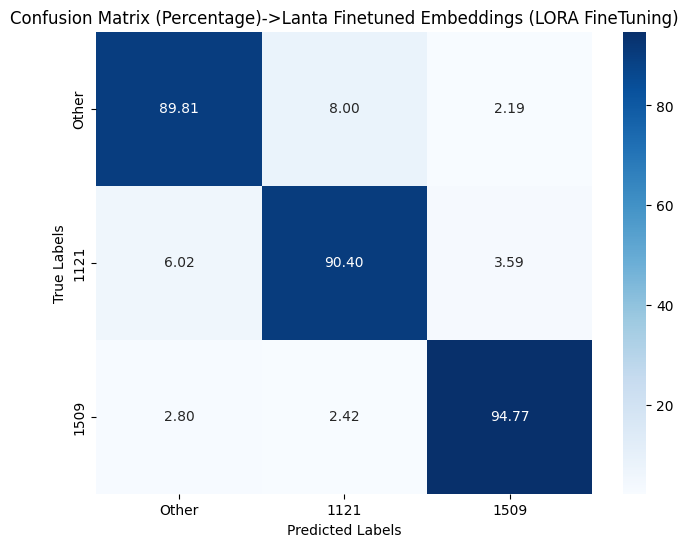

In [33]:
plot_confusion_matrix_percentage(y_test_encoded, predicted_classes, ['Other', '1121', '1509'])

In [34]:
y_test_keys

array(['Pusa 1121 Basmati', 'Pusa 1121 Basmati', 'Pusa 1121 Basmati', ...,
       'Pusa 1121 Basmati', 'Pusa 1121 Basmati', 'Pusa 1121 Basmati'],
      dtype='<U17')

In [35]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1509 Basmati'): 2}

In [36]:
import pandas as pd

idx_to_class = {v: k for k, v in class_indices.items()}
# Convert predicted class indices to actual class names
predicted_class_names = np.array([idx_to_class[idx] for idx in predicted_classes])
df = pd.DataFrame({'key_image_name': y_test_keys, 'prediction': predicted_class_names})

# Group by key_image_name and count prediction occurrences
result = df.groupby(['key_image_name', 'prediction']).size().unstack(fill_value=0)


In [37]:
result

prediction,Other,Pusa 1121 Basmati,Pusa 1509 Basmati
key_image_name,,,
PB1 Basmati,869,74,5
Pusa,1088,61,9
Pusa 1121 Basmati,359,5394,214
Pusa 1401 Basmati,1536,243,32
Pusa 1509 Basmati,162,140,5477
Pusa 1718 Basmati,461,180,13
Sharbati Rice,1352,12,20
Sugandha Basmati,1466,54,69
TAJ,736,45,35


In [38]:
result.to_csv("9AprilTrinaryLORA.csv")

In [59]:
import numpy as np
import pandas as pd

def multilabel_confusion_matrix_summary(y_true, y_pred, class_names=None, normalize=False):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    num_classes = y_true.shape[1]

    matrix = np.zeros((num_classes, num_classes), dtype=int)

    for i in range(len(y_true)):
        true_indices = np.where(y_true[i] == 1)[0]
        pred_indices = np.where(y_pred[i] == 1)[0]

        for ti in true_indices:
            for pi in pred_indices:
                matrix[ti, pi] += 1

    if normalize:
        matrix = matrix.astype(float)
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix = np.divide(matrix, row_sums, where=row_sums != 0) * 100

    df = pd.DataFrame(matrix)
    df.columns = class_names
    df.index = class_names
    return df




In [ ]:
y_true = np.array([
    [1, 0, 0, 0, 0],  # true: 1718
    [1, 0, 0, 0, 0],  # true: 1718
    [0, 1, 0, 0, 0],  # true: 1509
    [0, 0, 1, 0, 0],  # true: 1121
    [0, 0, 0, 1, 0],  # true: 1401
    [0, 0, 0, 0, 1],  # true: other
])

y_pred = np.array([
    [1, 0, 0, 0, 0],  # pred: 1718
    [0, 1, 0, 0, 0],  # pred: 1509
    [1, 1, 0, 0, 0],  # pred: 1718, 1509
    [0, 0, 1, 0, 1],  # pred: 1121, other
    [0, 0, 0, 0, 1],  # pred: other
    [0, 0, 0, 0, 1],  # pred: other
])

class_names = ["1718", "1509", "1121", "1401", "other"]

df = multilabel_confusion_matrix_summary(y_true, y_pred, class_names, normalize=False)
print(df)


       1718  1509  1121  1401  other
1718      1     1     0     0      0
1509      1     1     0     0      0
1121      0     0     1     0      1
1401      0     0     0     0      1
other     0     0     0     0      1


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_heatmap(df, title="Multilabel Confusion Matrix", cmap="Blues", fmt=".0f"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(df, annot=True, fmt=fmt, cmap=cmap, cbar=True)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


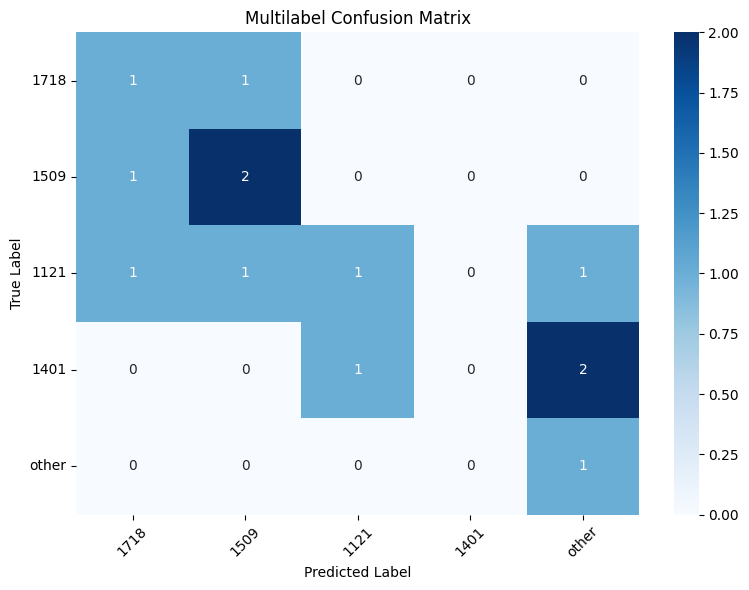

In [62]:
plot_confusion_matrix_heatmap(df)